In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../data/processed/Fraud_Data_Cleaned.csv")

In [8]:
X = df.drop('class', axis=1)
y = df['class']

In [9]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

Remove Non-Numeric Columns

In [11]:
X = X.select_dtypes(include=np.number)

In [12]:
X = pd.get_dummies(X, drop_first=True)

Stratified Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [16]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [17]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [18]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [19]:
y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

In [20]:
print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("AUC-PR:",
      average_precision_score(y_test, y_prob_lr))

print(classification_report(y_test, y_pred_lr))

F1 Score: 0.10876132930513595
AUC-PR: 0.724469435669471
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



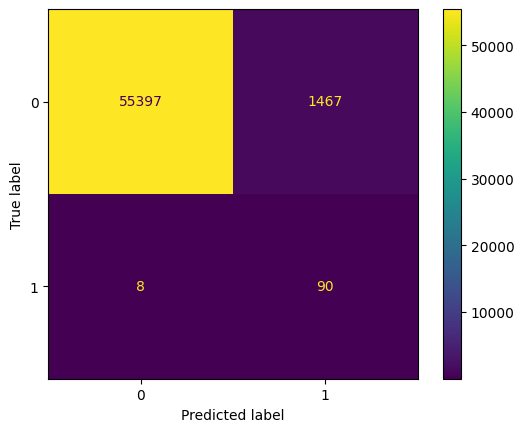

In [21]:
cm = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [2]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score, make_scorer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

def apply_smote(X_train, y_train):
    """Applies synthetic oversampling to the minority class exclusively on the training split."""
    print(f"Distribution before SMOTE: {np.bincount(y_train)}")
    smote = SMOTE(sampling_strategy=0.25, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print(f"Distribution after SMOTE: {np.bincount(y_res)}")
    return X_res, y_res

def calc_pr_auc(y_true, y_probas):
    p, r, _ = precision_recall_curve(y_true, y_probas)
    return auc(r, p)

def execute_model_training(X_train_res, y_train_res, X_test, y_test):
    """Trains baseline (Logistic Regression) and Ensemble (XGBoost) models under 5-Fold Stratified CV."""
    pr_scorer = make_scorer(calc_pr_auc, response_method='predict_proba')
    cv_metrics = {'f1': 'f1', 'auc_pr': pr_scorer}
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 1. Baseline Model Cross Validation
    lr_baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr_cv = cross_validate(lr_baseline, X_train_res, y_train_res, cv=cv_strategy, scoring=cv_metrics)
    
    # 2. Advanced Tree Ensemble Cross Validation
    xgb_ensemble = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
    xgb_cv = cross_validate(xgb_ensemble, X_train_res, y_train_res, cv=cv_strategy, scoring=cv_metrics)
    
    # Final Model Optimization Fits
    lr_baseline.fit(X_train_res, y_train_res)
    xgb_ensemble.fit(X_train_res, y_train_res)
    
    # Evaluation Report Runner
    for model, name in [(lr_baseline, "Logistic Regression"), (xgb_ensemble, "XGBoost Classifier")]:
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        test_auc_pr = calc_pr_auc(y_test, probs)
        
        print(f"\n=== {name} Test Set Performance ===")
        print(f"Confusion Matrix:\n{confusion_matrix(y_test, preds)}")
        print(classification_report(y_test, preds))
        print(f"Test Set AUC-PR: {test_auc_pr:.4f}")
        
    return lr_baseline, xgb_ensemble